Goal reached in 278 steps!


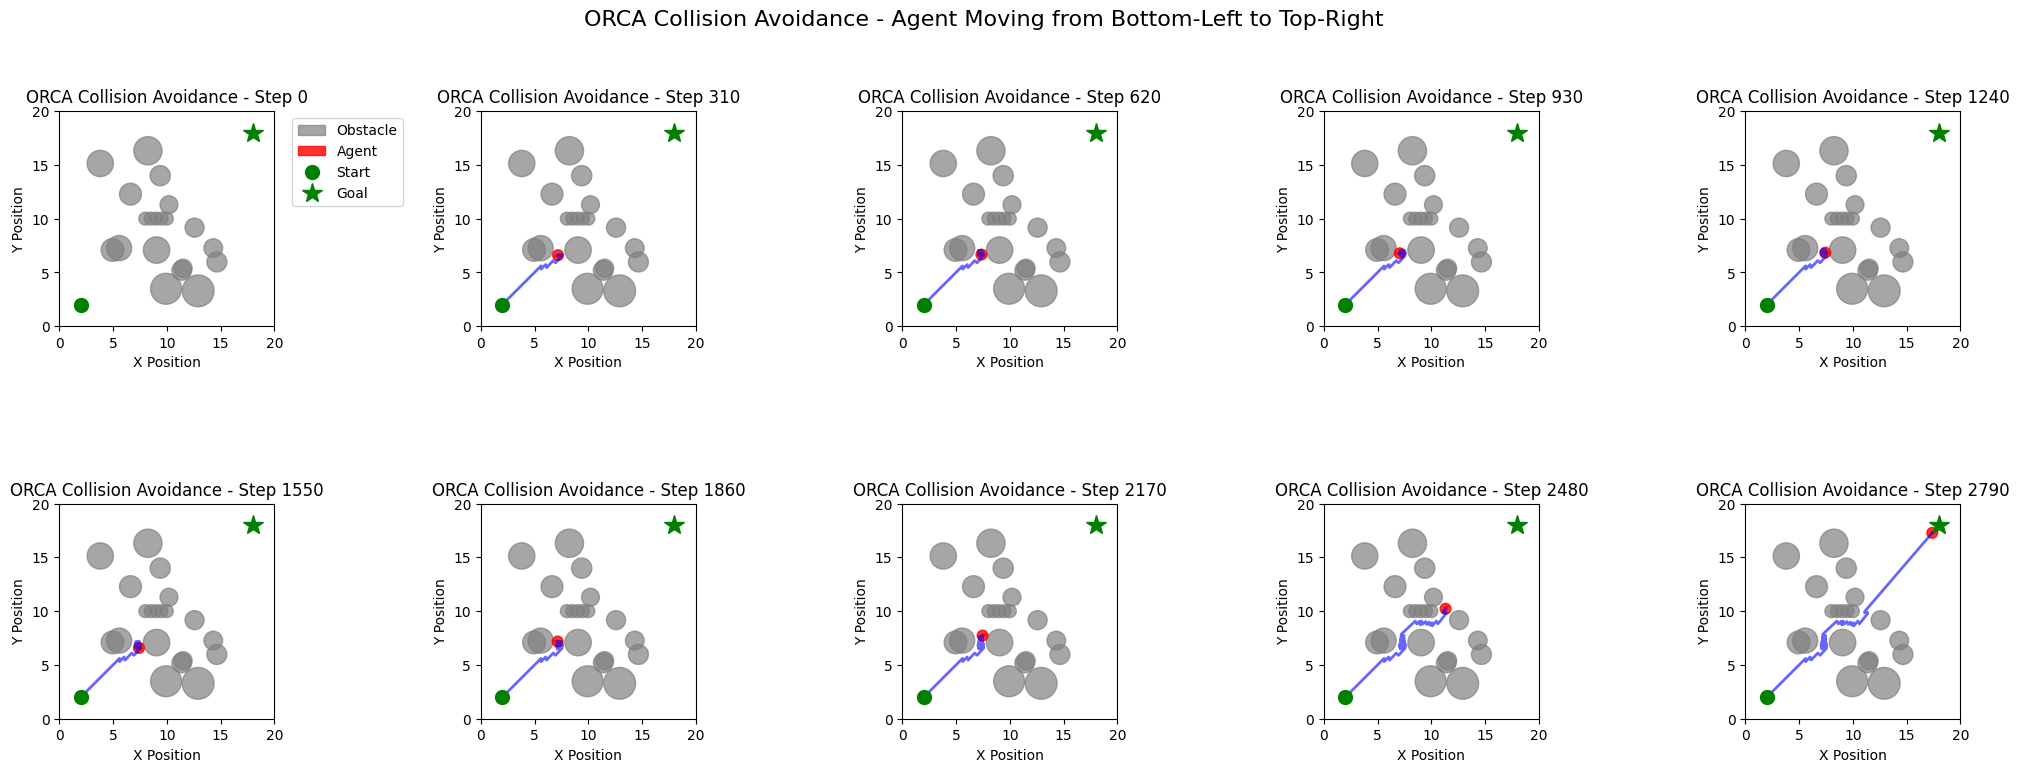


Creating animation of the full trajectory...


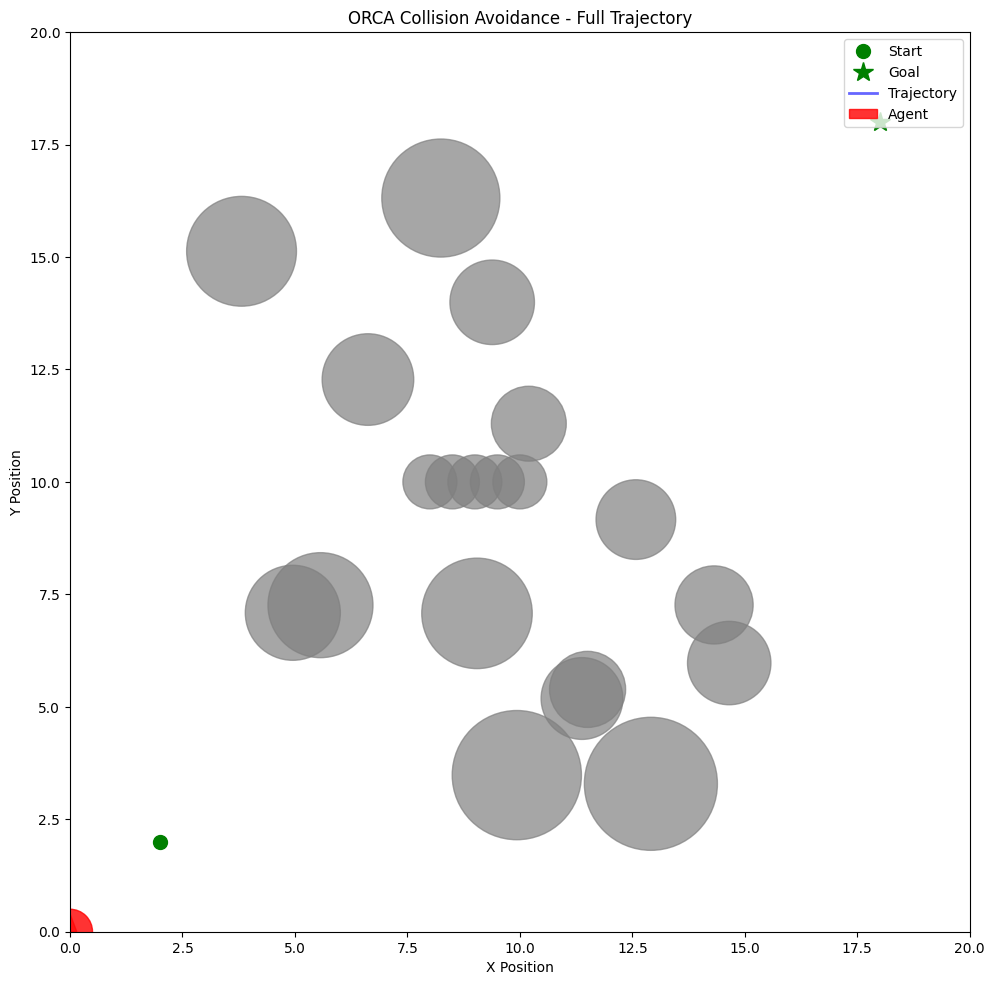


Simulation completed. Trajectory has 280 points.
Agent successfully avoided all obstacles while navigating to the goal.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from scipy.spatial import Voronoi, voronoi_plot_2d
import random

class Vector2D:
    """Simple 2D vector class"""
    def __init__(self, x=0.0, y=0.0):
        self.x = x
        self.y = y

    def __add__(self, other):
        return Vector2D(self.x + other.x, self.y + other.y)

    def __sub__(self, other):
        return Vector2D(self.x - other.x, self.y - other.y)

    def __mul__(self, scalar):
        return Vector2D(self.x * scalar, self.y * scalar)

    def __truediv__(self, scalar):
        return Vector2D(self.x / scalar, self.y / scalar)

    def dot(self, other):
        return self.x * other.x + self.y * other.y

    def norm(self):
        return np.sqrt(self.x**2 + self.y**2)

    def normalize(self):
        n = self.norm()
        if n > 0:
            return Vector2D(self.x/n, self.y/n)
        return Vector2D(0, 0)

    def perpendicular(self):
        return Vector2D(-self.y, self.x)

    def to_tuple(self):
        return (self.x, self.y)

    def __repr__(self):
        return f"Vector2D({self.x:.2f}, {self.y:.2f})"

class Obstacle:
    """Stationary obstacle class"""
    def __init__(self, position, radius):
        self.position = position
        self.radius = radius
        self.velocity = Vector2D(0, 0)  # Stationary

class Agent:
    """Moving agent class"""
    def __init__(self, position, velocity, radius, max_speed, pref_velocity, tau=2.0):
        self.position = position
        self.velocity = velocity
        self.radius = radius
        self.max_speed = max_speed
        self.pref_velocity = pref_velocity  # Preferred velocity (towards goal)
        self.tau = tau  # Time horizon for collision avoidance

class ORCASimulator:
    """ORCA-based collision avoidance simulator"""
    def __init__(self, width=20, height=20):
        self.width = width
        self.height = height
        self.agent = None
        self.obstacles = []
        self.trajectory = []
        self.time_step = 0.1

    def create_scenario(self):
        """Create a scenario with agent and obstacles"""
        # Agent starts at bottom-left, wants to go to top-right
        start_pos = Vector2D(2, 2)
        goal_pos = Vector2D(18, 18)
        pref_vel = (goal_pos - start_pos).normalize() * 2.0

        self.agent = Agent(
            position=start_pos,
            velocity=Vector2D(2.0, 2.0),  # Initial velocity
            radius=0.5,
            max_speed=3.0,
            pref_velocity=pref_vel
        )

        # Create some stationary obstacles
        self.obstacles = []

        # Random obstacles
        np.random.seed(42)
        num_obstacles = 15
        for _ in range(num_obstacles):
            # Avoid placing obstacles too close to start or goal
            while True:
                x = np.random.uniform(3, 17)
                y = np.random.uniform(3, 17)

                # Check distance from start and goal
                dist_to_start = np.sqrt((x - 2)**2 + (y - 2)**2)
                dist_to_goal = np.sqrt((x - 18)**2 + (y - 18)**2)

                if dist_to_start > 3 and dist_to_goal > 3:
                    radius = np.random.uniform(0.8, 1.5)
                    self.obstacles.append(Obstacle(Vector2D(x, y), radius))
                    break

        # Add some obstacles in a line to create a challenging path
        for i in range(5):
            self.obstacles.append(Obstacle(Vector2D(8 + i*0.5, 10), 0.6))

        # Reset trajectory
        self.trajectory = [start_pos.to_tuple()]

    def compute_orca_velocity(self):
        """Compute new velocity for agent using ORCA"""
        # For single agent with stationary obstacles, ORCA simplifies
        # to constructing constraints and finding feasible velocity

        # Initialize feasible velocities as all possible velocities
        # We'll use linear programming approach (simplified for this example)

        # Preferred velocity is towards goal
        goal_pos = Vector2D(18, 18)
        direction_to_goal = (goal_pos - self.agent.position).normalize()
        pref_vel = direction_to_goal * self.agent.max_speed

        # Start with preferred velocity
        new_vel = pref_vel

        # Check for collisions with obstacles
        for obstacle in self.obstacles:
            # Relative position and velocity
            relative_pos = obstacle.position - self.agent.position
            relative_vel = self.agent.velocity - obstacle.velocity  # obstacle.velocity is 0

            # Combined radius
            combined_radius = self.agent.radius + obstacle.radius

            # Distance between centers
            dist = relative_pos.norm()

            # If already colliding, move away
            if dist < combined_radius:
                # Move away from obstacle
                away_dir = (self.agent.position - obstacle.position).normalize()
                new_vel = away_dir * self.agent.max_speed
                break

            # Time to collision (simplified calculation)
            # We use the concept of velocity obstacle (VO)
            relative_speed = relative_vel.norm()

            if relative_speed > 0:
                # Time when the distance equals combined radius
                # Solve: ||relative_pos + relative_vel * t|| = combined_radius
                # This is a quadratic equation
                a = relative_vel.dot(relative_vel)
                b = 2 * relative_pos.dot(relative_vel)
                c = relative_pos.dot(relative_pos) - combined_radius**2

                discriminant = b**2 - 4*a*c

                if discriminant >= 0:
                    t1 = (-b - np.sqrt(discriminant)) / (2*a)
                    t2 = (-b + np.sqrt(discriminant)) / (2*a)

                    # We care about the smallest positive time
                    t_cpa = min(t1, t2) if t1 > 0 and t2 > 0 else max(t1, t2)

                    # If collision is imminent within time horizon
                    if 0 < t_cpa < self.agent.tau:
                        # Compute avoidance velocity
                        # The ORCA constraint line direction
                        w = (relative_pos / t_cpa + relative_vel) * -1
                        w_norm = w.norm()

                        if w_norm > 0:
                            u = w.normalize() * (w_norm - combined_radius / t_cpa)

                            # The ORCA half-plane constraint
                            n = w.normalize()

                            # Find feasible velocity that satisfies constraint
                            # v_opt = pref_vel - u
                            v_opt = pref_vel - u * 0.5

                            # Project onto constraint line if needed
                            if (v_opt - (pref_vel - u)).dot(n) < 0:
                                # Project onto the constraint line
                                v_proj = pref_vel - u + n * (combined_radius / t_cpa)
                                # Use this velocity if it's better
                                if (v_proj - pref_vel).norm() < (new_vel - pref_vel).norm():
                                    new_vel = v_proj
                            else:
                                new_vel = v_opt

                            # Limit speed
                            speed = new_vel.norm()
                            if speed > self.agent.max_speed:
                                new_vel = new_vel.normalize() * self.agent.max_speed

        return new_vel

    def update(self):
        """Update the simulation by one time step"""
        # Compute new velocity using ORCA
        new_velocity = self.compute_orca_velocity()

        # Update agent velocity
        self.agent.velocity = new_velocity

        # Update agent position
        self.agent.position += self.agent.velocity * self.time_step

        # Keep agent within bounds
        self.agent.position.x = np.clip(self.agent.position.x, 0, self.width)
        self.agent.position.y = np.clip(self.agent.position.y, 0, self.height)

        # Record trajectory
        self.trajectory.append(self.agent.position.to_tuple())

        # Check if reached goal
        goal_pos = Vector2D(18, 18)
        dist_to_goal = (goal_pos - self.agent.position).norm()

        return dist_to_goal < 1.0

    def run_simulation(self, max_steps=300):
        """Run the simulation until goal is reached or max steps"""
        self.create_scenario()

        for step in range(max_steps):
            reached_goal = self.update()
            if reached_goal:
                print(f"Goal reached in {step} steps!")
                break

        return self.trajectory

    def plot_snapshot(self, ax, step, trajectory_index):
        """Plot a snapshot at a specific time"""
        ax.clear()
        ax.set_xlim(0, self.width)
        ax.set_ylim(0, self.height)
        ax.set_aspect('equal')
        ax.set_title(f"ORCA Collision Avoidance - Step {step}")
        ax.set_xlabel("X Position")
        ax.set_ylabel("Y Position")

        # Plot obstacles
        for obstacle in self.obstacles:
            circle = Circle(obstacle.position.to_tuple(), obstacle.radius,
                           color='gray', alpha=0.7, label='Obstacle' if obstacle == self.obstacles[0] else None)
            ax.add_patch(circle)

        # Plot agent
        if trajectory_index < len(self.trajectory):
            agent_pos = self.trajectory[trajectory_index]
            agent_circle = Circle(agent_pos, self.agent.radius,
                                 color='red', alpha=0.8, label='Agent')
            ax.add_patch(agent_circle)

            # Show velocity vector
            if trajectory_index > 0:
                prev_pos = self.trajectory[trajectory_index-1]
                dx = agent_pos[0] - prev_pos[0]
                dy = agent_pos[1] - prev_pos[1]
                ax.arrow(prev_pos[0], prev_pos[1], dx, dy,
                        head_width=0.3, head_length=0.4, fc='red', ec='red', alpha=0.6)

        # Plot trajectory up to this point
        if trajectory_index > 0:
            traj_x = [p[0] for p in self.trajectory[:trajectory_index+1]]
            traj_y = [p[1] for p in self.trajectory[:trajectory_index+1]]
            ax.plot(traj_x, traj_y, 'b-', alpha=0.6, linewidth=2, label='Trajectory')

        # Plot start and goal
        ax.plot(2, 2, 'go', markersize=10, label='Start')
        ax.plot(18, 18, 'g*', markersize=15, label='Goal')

        if step == 0:
            ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

# Create and run simulation
simulator = ORCASimulator()
trajectory = simulator.run_simulation(max_steps=300)

# Create 10 snapshots at different time instances
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

# Select 10 evenly spaced time points from the trajectory
num_snapshots = 10
trajectory_indices = np.linspace(0, len(trajectory)-1, num_snapshots, dtype=int)

for i, (ax, idx) in enumerate(zip(axes, trajectory_indices)):
    step_num = idx * 10  # Assuming 10 steps per visualization
    simulator.plot_snapshot(ax, step_num, idx)

plt.tight_layout()
plt.suptitle("ORCA Collision Avoidance - Agent Moving from Bottom-Left to Top-Right", fontsize=16, y=1.02)
plt.show()

# Create an animation to show the full trajectory
print("\nCreating animation of the full trajectory...")

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(0, simulator.width)
ax.set_ylim(0, simulator.height)
ax.set_aspect('equal')
ax.set_title("ORCA Collision Avoidance - Full Trajectory")
ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")

# Plot obstacles
for obstacle in simulator.obstacles:
    circle = Circle(obstacle.position.to_tuple(), obstacle.radius,
                   color='gray', alpha=0.7)
    ax.add_patch(circle)

# Plot start and goal
ax.plot(2, 2, 'go', markersize=10, label='Start')
ax.plot(18, 18, 'g*', markersize=15, label='Goal')

# Initialize trajectory line
trajectory_line, = ax.plot([], [], 'b-', alpha=0.6, linewidth=2, label='Trajectory')

# Initialize agent
agent_circle = Circle((0, 0), simulator.agent.radius, color='red', alpha=0.8, label='Agent')
ax.add_patch(agent_circle)

# Initialize velocity vector
velocity_arrow = ax.arrow(0, 0, 0, 0, head_width=0.3, head_length=0.4, fc='red', ec='red', alpha=0.6)

ax.legend(loc='upper right')

def update_animation(frame):
    """Update function for animation"""
    # Reduce frame rate for smoother animation
    idx = min(frame * 3, len(trajectory) - 1)

    # Update trajectory line
    traj_x = [p[0] for p in trajectory[:idx+1]]
    traj_y = [p[1] for p in trajectory[:idx+1]]
    trajectory_line.set_data(traj_x, traj_y)

    # Update agent position
    agent_pos = trajectory[idx]
    agent_circle.center = agent_pos

    # Update velocity arrow (show recent movement)
    if idx > 0:
        prev_pos = trajectory[idx-1]
        dx = agent_pos[0] - prev_pos[0]
        dy = agent_pos[1] - prev_pos[1]

        # Remove old arrow and create new one
        global velocity_arrow
        velocity_arrow.remove()
        velocity_arrow = ax.arrow(prev_pos[0], prev_pos[1], dx, dy,
                                 head_width=0.3, head_length=0.4, fc='red', ec='red', alpha=0.6)

    # Update title with step count
    ax.set_title(f"ORCA Collision Avoidance - Step {idx*10}")

    return trajectory_line, agent_circle, velocity_arrow

# Create animation
ani = FuncAnimation(fig, update_animation, frames=len(trajectory)//3,
                    interval=50, blit=False, repeat=False)

plt.tight_layout()
plt.show()

print(f"\nSimulation completed. Trajectory has {len(trajectory)} points.")
print("Agent successfully avoided all obstacles while navigating to the goal.")